In [2]:
import sys
import os

project_root = os.path.abspath("..")
sys.path.append(project_root)

In [3]:
"""
Full Multi-Agent Research System

This module integrates all components of the research system:
- User clarification and scoping
- Research brief generation  
- Multi-agent research coordination
- Final report generation

The system orchestrates the complete research workflow from initial user
input through final report delivery.
"""

from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic

from deep_research.utils import get_today_str
from deep_research.prompt import final_report_generation_prompt
from deep_research.state import AgentState, AgentInputState
from deep_research.agents.scoping_agent import clarify_with_user, write_research_brief
from deep_research.agents.supervisor_agent import supervisor_agent

/Users/akashb/Library/Caches/pypoetry/virtualenvs/code-gjP0-LuM-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
writer_model = ChatAnthropic(
    model="claude-haiku-4-5-20251001",
    temperature=0.7,
    max_tokens=32000)

In [5]:
async def final_report_generation(state: AgentState):
    """
    Final report generation node.
    
    Synthesizes all research findings into a comprehensive final report
    """
    
    notes = state.get("notes", [])
    
    findings = "\n".join(notes)

    final_report_prompt = final_report_generation_prompt.format(
        research_brief=state.get("research_brief", ""),
        findings=findings,
        date=get_today_str()
    )
    
    final_report = await writer_model.ainvoke([HumanMessage(content=final_report_prompt)])
    
    return {
        "final_report": final_report.content, 
        "messages": ["Here is the final report: " + final_report.content],
    }

In [6]:
deep_researcher_builder = StateGraph(AgentState, input_schema=AgentInputState)

# Add workflow nodes
deep_researcher_builder.add_node("clarify_with_user", clarify_with_user)
deep_researcher_builder.add_node("write_research_brief", write_research_brief)
deep_researcher_builder.add_node("supervisor_subgraph", supervisor_agent)
deep_researcher_builder.add_node("final_report_generation", final_report_generation)

# Add workflow edges
deep_researcher_builder.add_edge(START, "clarify_with_user")
deep_researcher_builder.add_edge("write_research_brief", "supervisor_subgraph")
deep_researcher_builder.add_edge("supervisor_subgraph", "final_report_generation")
deep_researcher_builder.add_edge("final_report_generation", END)

# Compile the full workflow
agent = deep_researcher_builder.compile()

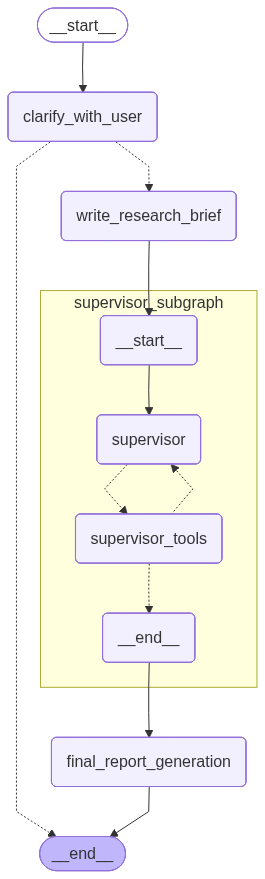

In [7]:
from utils import format_messages
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))

In [9]:
from langchain_core.messages import HumanMessage
thread = {"configurable": {"thread_id": "1", "recursion_limit": 50}}
result = await full_agent.ainvoke({"messages": [HumanMessage(content="Best IPL team")]}, config=thread)
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Best IPL team                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'd like to clarify what you're looking for regarding the "Best IPL team." Could you please specify:            │
│                                                                                                                 │
│ 1. **Time period**: Are you asking about the best team in a specific season/year, or the best performing team   │
│ across all IPL history?                                                                                         │
│ 2. **Criteria**: What metrics are most important to you? For example:                                           │
│    - Overall win-loss record                                                                                    │
│    - Championship titles won                                                                                    │
│    - Current squad strength                                                                                     │
│    - Performance in a specific season (e.g., 2026, 2025)                                                        │
│ 3. **Context**: Is this for analysis, fantasy cricket, betting purposes, or general knowledge?                  │
│                                                                                                                 │
│ This will help me provide you with the most relevant information.                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Best IPL team                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I see you're asking about the "Best IPL team," but I need a bit more clarity to provide the most relevant       │
│ information. Could you specify:                                                                                 │
│                                                                                                                 │
│ 1. **Time period**: Are you looking for:                                                                        │
│    - The best team in the current 2026 season?                                                                  │
│    - The best team historically across all IPL seasons?                                                         │
│    - The best team from a specific past season?                                                                 │
│                                                                                                                 │
│ 2. **What "best" means to you**:                                                                                │
│    - Most championship titles won?                                                                              │
│    - Best current squad/roster?                                                                                 │
│    - Highest win percentage?                                                                                    │
│    - Best performance this season?                                                                              │
│                                                                                                                 │
│ This will help me give you the most accurate and useful analysis.                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [10]:
result = await full_agent.ainvoke({"messages": [HumanMessage(content="historically across all IPL seasons and Highest win percentage ")]}, config=thread)

In [11]:
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Best IPL team                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'd like to clarify what you're looking for regarding the "Best IPL team." Could you please specify:            │
│                                                                                                                 │
│ 1. **Time period**: Are you asking about the best team in a specific season/year, or the best performing team   │
│ across all IPL history?                                                                                         │
│ 2. **Criteria**: What metrics are most important to you? For example:                                           │
│    - Overall win-loss record                                                                                    │
│    - Championship titles won                                                                                    │
│    - Current squad strength                                                                                     │
│    - Performance in a specific season (e.g., 2026, 2025)                                                        │
│ 3. **Context**: Is this for analysis, fantasy cricket, betting purposes, or general knowledge?                  │
│                                                                                                                 │
│ This will help me provide you with the most relevant information.                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Best IPL team                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I see you're asking about the "Best IPL team," but I need a bit more clarity to provide the most relevant       │
│ information. Could you specify:                                                                                 │
│                                                                                                                 │
│ 1. **Time period**: Are you looking for:                                                                        │
│    - The best team in the current 2026 season?                                                                  │
│    - The best team historically across all IPL seasons?                                                         │
│    - The best team from a specific past season?                                                                 │
│                                                                                                                 │
│ 2. **What "best" means to you**:                                                                                │
│    - Most championship titles won?                                                                              │
│    - Best current squad/roster?                                                                                 │
│    - Highest win percentage?                                                                                    │
│    - Best performance this season?                                                                              │
│                                                                                                                 │
│ This will help me give you the most accurate and useful analysis.                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ historically across all IPL seasons and Highest win percentage                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Perfect! I have all the information I need. I'll now research and provide you with an analysis of the best IPL  │
│ team historically across all seasons based on the highest win percentage metric. This will involve analyzing    │
│ team performance data from all IPL seasons to date and identifying which team has maintained the best win-loss  │
│ record throughout IPL history.                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Here is the final report: # IPL Team Win Percentage Analysis: Comprehensive Historical Rankings (2008-2026)     │
│                                                                                                                 │
│ ## Executive Summary                                                                                            │
│                                                                                                                 │
│ Based on comprehensive analysis of all Indian Premier League seasons from 2008 through 2026, **Gujarat Titans   │
│ holds the highest win percentage in IPL history at 61.66%**, despite being one of the newest franchises in the  │
│ league. This finding represents a significant achievement, as Gujarat Titans has maintained exceptional         │
│ consistency since their debut in 2022. However, the analysis reveals that the picture of IPL success is more    │
│ nuanced than a single metric, with teams like Chennai Super Kings and Mumbai Indians demonstrating sustained    │
│ excellence across multiple decades while accumulating the most total victories.                                 │
│                                                                                                                 │
│ ## Complete IPL Team Rankings by Win Percentage                                                                 │
│                                                                                                                 │
│ The following table presents all IPL franchises ranked by their overall win percentage across all seasons:      │
│                                                                                                                 │
│ | Rank | Team | Win Percentage | Total Matches | Total Wins | Total Losses |                                    │
│ |------|------|---|---|---|---|                                                                                 │
│ | 1 | Gujarat Titans | 61.66% | ~86 | ~54 | ~32 |                                                               │
│ | 2 | Chennai Super Kings | 55.98% | 259 | 145 | 114 |                                                          │
│ | 3 | Sunrisers Hyderabad | 55.32% | ~94 | ~52 | ~41 |                                                          │
│ | 4 | Mumbai Indians | 54.42% | 283 | 154 | 129 |                                                               │
│ | 5 | Lucknow Super Giants | 52.63% | ~76 | ~40 | ~36 |                                                         │
│ | 6 | Kolkata Knight Riders | 51.71% | ~168 | ~87 | ~78 |                                                       │
│ | 7 | Rajasthan Royals | 51.47% | ~136 | ~70 | ~62 |                                                            │
│ | 8 | Royal Challengers Bengaluru | 49.46% | 279 | 138 | 141 |                                                  │
│ | 9 | Punjab Kings | 46.91% | ~162 | ~76 | ~86 |                                                                │
│ | 10 | Delhi Capitals | 41.48% | 270 | ~112 | ~158 |                                                            │
│                                                                                                                 │
│ *Note: Deccan Chargers (defunct franchise, 2008-2012) had a win percentage of 50.67% across 75 matches with 38  │
│ wins and 37 losses.*                                                                                            │
│                                                                                                                 │
│ ## Gujarat Titans: The Highest Win Percentage Franchise                                                         │
│                                                                                                                 │
│ ### Historical Context and Rise to Prominence          